In [1]:
import pickle
import matplotlib.pyplot as plt
import japanize_matplotlib
import pywt
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
from pathlib import Path

In [2]:
# data_file_path = "../data/20250512/processed/ishii_task2_merged.pkl"
# data_file_path = "../data/bcidatasetIV2a/processed/merged.pkl"
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"

In [3]:
# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs']  # エポックデータ
labels = data['labels']  # ラベル
epochs_list = epochs.get_data()  # エポックのリスト
epochs_list *= 1e6  # 単位をμVに変換
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス
fs = 2500

In [ ]:
# チャンネルごとに平均0, 標準偏差1に正規化
scaler = StandardScaler()
epochs_list = epochs_list.reshape(epochs_list.shape[0], -1)  # 2次元に変換
epochs_list = scaler.fit_transform(epochs_list)  # 元の形状に戻す
epochs_list = epochs_list.reshape(-1, epochs_list.shape[1] // 32, 32)  # 元の形状に戻す

ValueError: cannot reshape array of size 47253780 into shape (24611,32)

In [4]:
epochs_list.shape

(60, 63, 12501)

In [5]:
labels

array([1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1])

In [6]:
e0 = epochs_list[0, :, :]
e0c0 = epochs_list[0, 2, :]
e0c0

array([-11.47892656, -11.49365133, -11.50765645, ...,  -7.4569665 ,
        -7.30558514,  -7.13490628])

In [7]:
window_idx = 1
window_data = e0c0[window_idx*fs:(window_idx+1)*fs]

# e0c0をwavelet変換する
scales = np.arange(1, 64)
# Morlet waveletでCWT実行

coefficients, frequencies = pywt.cwt(window_data, scales, 'cmor', 1/fs)

/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


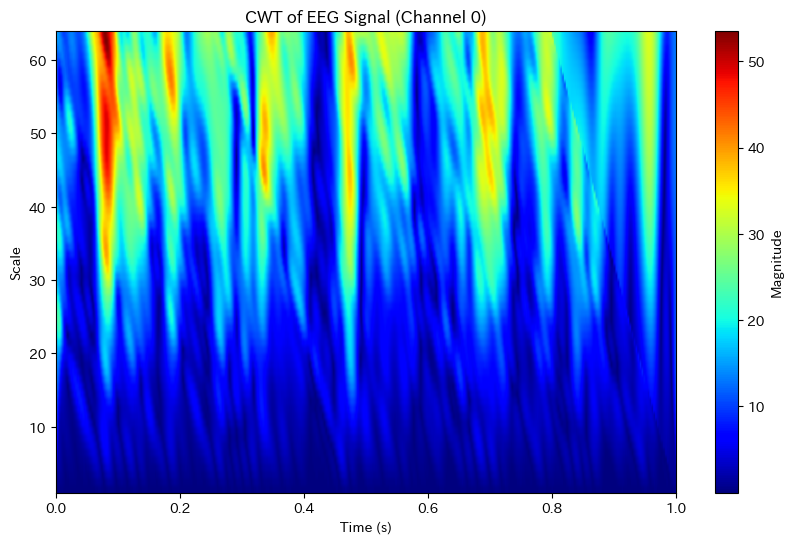

In [8]:
# Wavelet変換の結果をプロット
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), aspect='auto', extent=[0, len(window_data)/fs, 1, 64], cmap='jet', origin='lower')
plt.colorbar(label='Magnitude')
plt.title('CWT of EEG Signal (Channel 0)')
plt.xlabel('Time (s)')
plt.ylabel('Scale')
plt.show()

In [9]:
np.abs(coefficients)

array([[ 2.99752777,  0.71998775,  0.04162765, ...,  0.98584332,
         1.00641637,  1.69068725],
       [ 4.21734584,  2.93538803,  1.27014362, ...,  1.2755397 ,
         2.3626871 ,  4.12507915],
       [ 5.14762695,  4.60943036,  3.38325344, ...,  2.87193457,
         4.38840379,  5.37482585],
       ...,
       [13.79427627, 13.61691873, 13.47970542, ..., 13.14209738,
        13.16514981, 13.17964656],
       [14.76830931, 14.72522178, 14.69569175, ..., 13.11619552,
        13.13837898, 13.15247762],
       [15.33512679, 15.30437835, 15.26892133, ..., 13.18507862,
        13.19545748, 13.19618941]])

In [10]:
def calc_spectrum(data, fs):
    coefficients, frequencies = pywt.cwt(e0c0, scales, 'cmor', 1/fs)
    power = np.abs(coefficients) ** 2

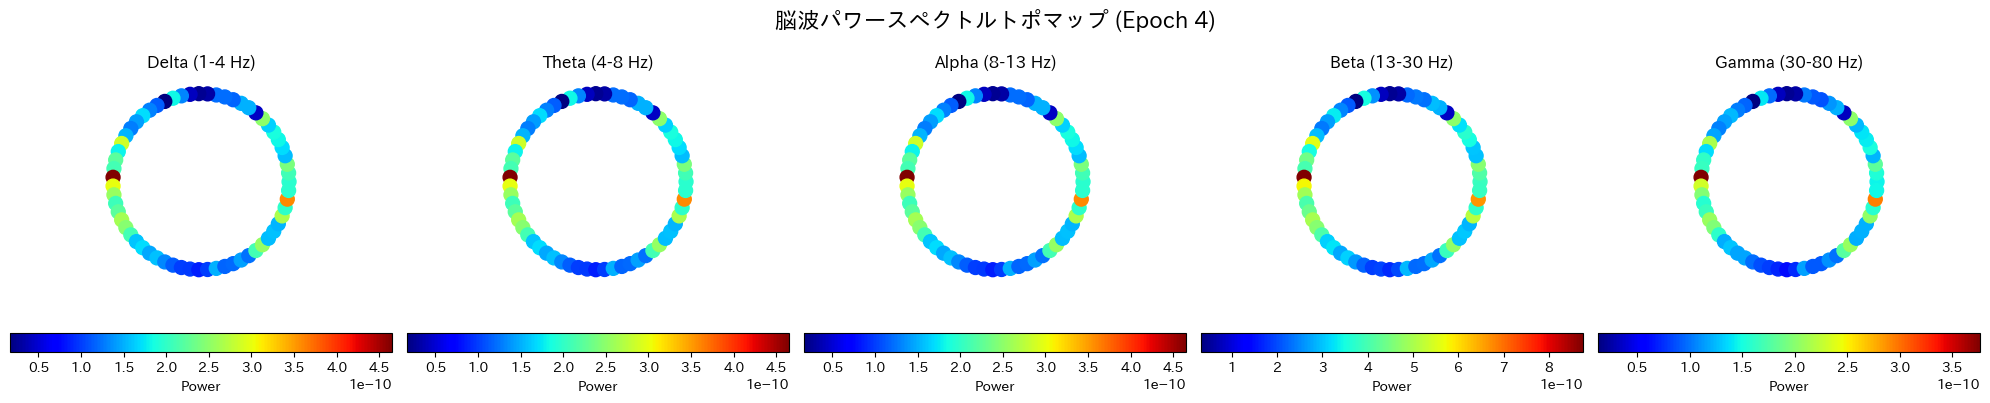

In [11]:
# 全チャンネルのwavelet変換の結果を格納するための配列
all_channel_power = np.zeros((epochs_list.shape[1], len(scales)))

# 例としてepochs_list[5]を使用（先ほどのe0c0はepochs_list[5, 2, :]だった）
epoch_idx = 4

# 各チャネルに対してwavelet変換を実行
for ch in range(epochs_list.shape[1]):
    signal = epochs_list[epoch_idx, ch, :]
    coeffs, _ = pywt.cwt(signal, scales, 'cmor', 1/fs)
    # パワーを計算（複素数の絶対値の二乗）
    power = np.abs(coeffs)**2
    # 各スケールの平均パワーを計算
    all_channel_power[ch, :] = np.mean(power, axis=1)

# 可視化するスケール/周波数バンドを選択
# デルタ（1-4Hz）、シータ（4-8Hz）、アルファ（8-13Hz）、ベータ（13-30Hz）、ガンマ（30-100Hz）
freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 80)
}

# 各周波数帯のインデックスを取得
band_indices = {}
for band, (low, high) in freq_bands.items():
    # 周波数からスケールのインデックスを見つける
    low_idx = np.where(frequencies <= high)[0][0] if any(frequencies <= high) else 0
    high_idx = np.where(frequencies >= low)[0][-1] if any(frequencies >= low) else -1
    band_indices[band] = (low_idx, high_idx)

# トポマップを作成
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'脳波パワースペクトルトポマップ (Epoch {epoch_idx})', fontsize=16)

# チャンネル位置の簡易的なマッピング（実際の電極位置に基づいて調整が必要）
# 本来はEEGキャップの電極配置に基づいて正確な位置情報が必要
# これは簡略化した例
n_channels = epochs_list.shape[1]
# 円状に電極を配置する簡易的なアプローチ
theta = np.linspace(0, 2*np.pi, n_channels, endpoint=False)
x = np.cos(theta)
y = np.sin(theta)
pos = np.vstack([x, y]).T

for i, (band, (low_idx, high_idx)) in enumerate(band_indices.items()):
    # 各バンドのパワーを計算
    band_power = np.mean(all_channel_power[:, low_idx:high_idx+1], axis=1)
    
    # トポマップのプロット
    im = axes[i].scatter(x, y, c=band_power, cmap='jet', s=100)
    axes[i].set_title(f'{band.capitalize()} ({freq_bands[band][0]}-{freq_bands[band][1]} Hz)')
    axes[i].set_xlim(-1.2, 1.2)
    axes[i].set_ylim(-1.2, 1.2)
    axes[i].set_aspect('equal')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], orientation='horizontal', label='Power')

plt.tight_layout()
plt.show()

In [12]:
epoch_idx = 4

# wavelet変換の、チャンネル
all_channel_power = np.zeros((epochs_list.shape[1], len(scales)))
for ch in range(epochs_list.shape[1]):
    signal = epochs_list[epoch_idx, ch, :]
    coeffs, _ = pywt.cwt(signal, scales, 'cmor', 1/fs)
    power = np.abs(coeffs)**2
    all_channel_power[ch, :] = np.mean(power, axis=1)

all_channel_power



array([[4.80641343e-14, 3.29640444e-13, 9.49408598e-13, ...,
        4.25907550e-10, 4.30931191e-10, 4.34949366e-10],
       [4.81899059e-14, 3.30790778e-13, 9.55206094e-13, ...,
        4.51441115e-10, 4.59605044e-10, 4.69524988e-10],
       [5.84482240e-14, 4.00276091e-13, 1.15078716e-12, ...,
        5.02393207e-10, 5.08884918e-10, 5.18181437e-10],
       ...,
       [5.31525130e-14, 3.63424449e-13, 1.03293968e-12, ...,
        4.14678313e-10, 4.16475589e-10, 4.18221146e-10],
       [1.01728479e-13, 6.85483756e-13, 1.91936297e-12, ...,
        7.18903072e-10, 7.26038218e-10, 7.32597026e-10],
       [4.60217393e-14, 3.16342410e-13, 9.12729688e-13, ...,
        4.14716963e-10, 4.20300362e-10, 4.27695077e-10]])

In [13]:
# labelsが9999のものを除外する
valid_indices = np.where(labels != 9999)[0]
epochs_list = epochs_list[valid_indices]
labels = labels[valid_indices]

In [14]:
epochs_list.shape

(60, 63, 5001)

In [15]:
labels

array([1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1])

In [16]:
# 1チャンネルのデータをWavelet変換してバンドパスパワーを計算
def calc_spectrum(data, band_count, fs):
    # サンプリングレートに応じてスケールを設定
    # 1-40Hzをカバーするスケール範囲を設定
    widths = np.arange(1, 64)
    
    # Morlet waveletでCWT実行
    coefficients, frequencies = pywt.cwt(data, widths, 'cmor', 1/fs)
    
    # パワーを計算（複素数の絶対値の二乗）
    power = np.abs(coefficients)**2
    
    # 1Hz-40Hzまでのband_count個のバンドパスパワーを計算
    band_lower = 1
    band_upper = 40
    band_powers = [None] * band_count
    
    for i in range(band_count):
        # 均等にバンドを分割
        band_min = band_lower + i * (band_upper - band_lower) / band_count
        band_max = band_lower + (i + 1) * (band_upper - band_lower) / band_count
        
        # 該当する周波数範囲のインデックスを取得
        band_indices = np.where((frequencies >= band_min) & (frequencies < band_max))[0]
        
        if len(band_indices) > 0:
            # 各バンドの平均パワーを計算
            band_powers[i] = np.mean(np.mean(power[band_indices, :], axis=1))
        else:
            # インデックスが見つからない場合は0を設定
            band_powers[i] = 0
    
    # band_powersの中にNoneがないことをassert
    assert all([v is not None for v in band_powers]), "Some band powers are None"
    
    return band_powers

In [17]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import multiprocessing

# 全エポックのすべてのチャンネルに対してバンドパワーを計算
band_count = 10
all_epochs_band_powers = np.zeros((epochs_list.shape[0], epochs_list.shape[1], band_count))

# 各チャンネルのバンドパワーを計算する関数
def process_channel(i, j):
    epoch_data = epochs_list[i, j, :]
    return calc_spectrum(epoch_data, band_count, fs)

# 各エポックを処理する関数
def process_epoch(i):
    results = np.zeros((epochs_list.shape[1], band_count))
    for j in range(epochs_list.shape[1]):
        results[j] = process_channel(i, j)
    return results

# 使用するCPUコア数を設定（-1は全コアを使用）
n_jobs = multiprocessing.cpu_count()
print(f"使用するCPUコア数: {n_jobs}")

# tqdmでプログレスバーを表示しながら並列処理
results = Parallel(n_jobs=n_jobs, verbose=0)(
    delayed(process_epoch)(i) for i in tqdm(range(epochs_list.shape[0]), desc='エポック処理中')
)

# 結果を配列に格納
for i, result in enumerate(results):
    all_epochs_band_powers[i] = result

print(f"Calculated band powers for {epochs_list.shape[0]} epochs, {epochs_list.shape[1]} channels, {band_count} frequency bands")

使用するCPUコア数: 8


エポック処理中:   0%|          | 0/60 [00:00<?, ?it/s]

/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)
/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)
/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family c

Calculated band powers for 60 epochs, 63 channels, 10 frequency bands
